# EDA - Mamografias CBIS-DDSM

Análise exploratória das imagens de mamografia preparadas em
`data/images/cbis-ddsm/` (splits train/val/test e classes benign/malignant).

In [1]:
# Celula 1 - Imports
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from src.cnn.dataset import CBIS_BASE_DIR, index_cbis_images

sns.set_theme(style='whitegrid')
print('Imports carregados')

Imports carregados


In [2]:
# Celula 2 - Visao geral do dataset de imagens
base = Path(CBIS_BASE_DIR)
index = index_cbis_images()

print('Diretorios do dataset:')
for split in ('train', 'val', 'test'):
    for label in ('benign', 'malignant'):
        d = base / split / label
        n = len(list(d.glob('*.jpg'))) + len(list(d.glob('*.png'))) if d.exists() else 0
        print(f'  {split}/{label}: {n} imagens')

print(f'\nTotal de imagens indexadas: {len(index)}')

Diretorios do dataset:
  train/benign: 207 imagens
  train/malignant: 168 imagens
  val/benign: 52 imagens
  val/malignant: 42 imagens
  test/benign: 55 imagens
  test/malignant: 35 imagens

Total de imagens indexadas: 559


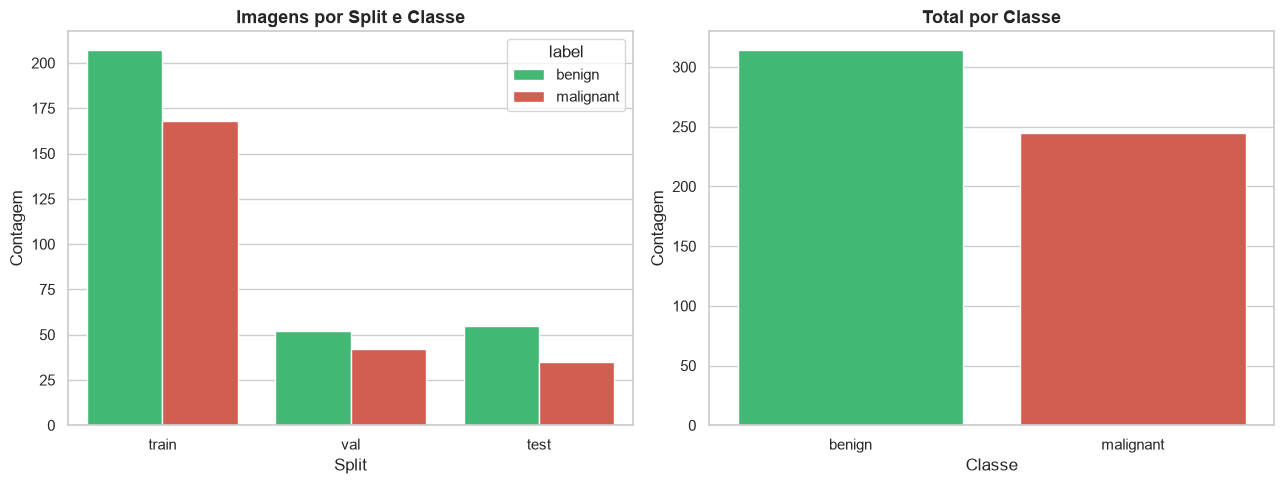

Contagem por split e classe:
label  benign  malignant
split                   
test       55         35
train     207        168
val        52         42


In [3]:
# Celula 3 - Distribuicao por split e classe
records = [{'split': meta['split'], 'label': meta['label']} for meta in index.values()]
df_imgs = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = ['train', 'val', 'test']
palette = {'benign': '#2ecc71', 'malignant': '#e74c3c'}
sns.countplot(data=df_imgs, x='split', hue='label', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Imagens por Split e Classe', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Contagem')

sns.countplot(data=df_imgs, x='label', hue='label', palette=palette, legend=False, ax=axes[1])
axes[1].set_title('Total por Classe', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Contagem')
plt.tight_layout()
plt.show()

print('Contagem por split e classe:')
print(df_imgs.groupby(['split', 'label']).size().unstack(fill_value=0))

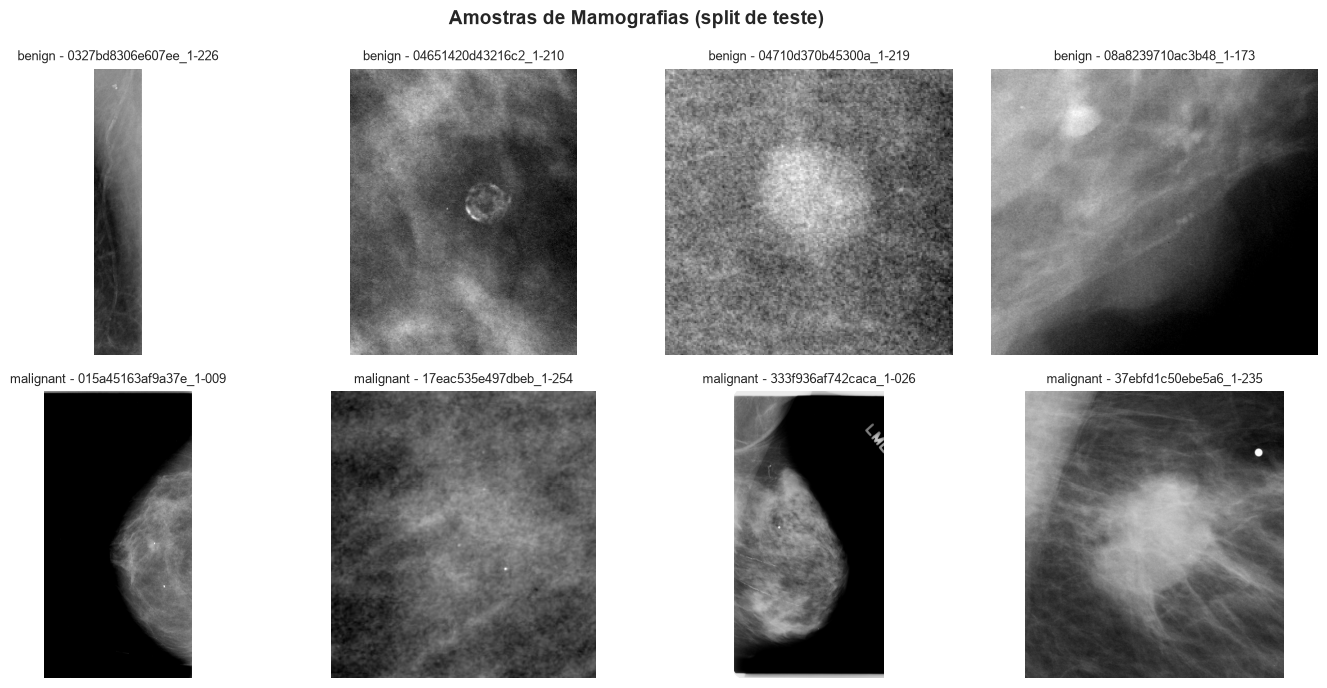

In [4]:
# Celula 4 - Amostras de imagens por classe
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for i, label in enumerate(['benign', 'malignant']):
    d = base / 'test' / label
    paths = sorted(d.glob('*.jpg')) + sorted(d.glob('*.png'))
    for j, path in enumerate(paths[:4]):
        img = Image.open(path).convert('L')
        axes[i * 4 + j].imshow(img, cmap='gray')
        axes[i * 4 + j].set_title(f'{label} - {path.name[:22]}', fontsize=9)
        axes[i * 4 + j].axis('off')
plt.suptitle('Amostras de Mamografias (split de teste)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Celula 5 - Estatisticas das imagens (dimensoes e intensidade)
# Amostra de ate 25 imagens por (split, classe) para agilizar
per_group = {}
for image_id, meta in index.items():
    per_group.setdefault((meta['split'], meta['label']), []).append(image_id)
limited = [image_id for group in per_group.values() for image_id in group[:25]]

stats = []
for image_id in limited:
    meta = index[image_id]
    with Image.open(meta['path']) as im:
        arr = np.array(im.convert('L'))
        stats.append({
            'path': str(meta['path']),
            'split': meta['split'],
            'label': meta['label'],
            'width': im.width,
            'height': im.height,
            'mean': arr.mean(),
            'std': arr.std(),
        })
df_stats = pd.DataFrame(stats)
print(f'Analisadas {len(df_stats)} imagens (ate 25 por split/classe).')
print('\nDimensoes medias por classe:')
print(df_stats.groupby('label')[['width', 'height']].median().round(0))
print('\nIntensidade media de pixel (0-255) por classe:')
print(df_stats.groupby('label')[['mean', 'std']].mean().round(2))

Analisadas 150 imagens (ate 25 por split/classe).

Dimensoes medias por classe:
           width  height
label                   
benign     466.0   448.0
malignant  741.0   617.0

Intensidade media de pixel (0-255) por classe:
            mean    std
label                  
benign     89.81  49.53
malignant  96.77  53.53


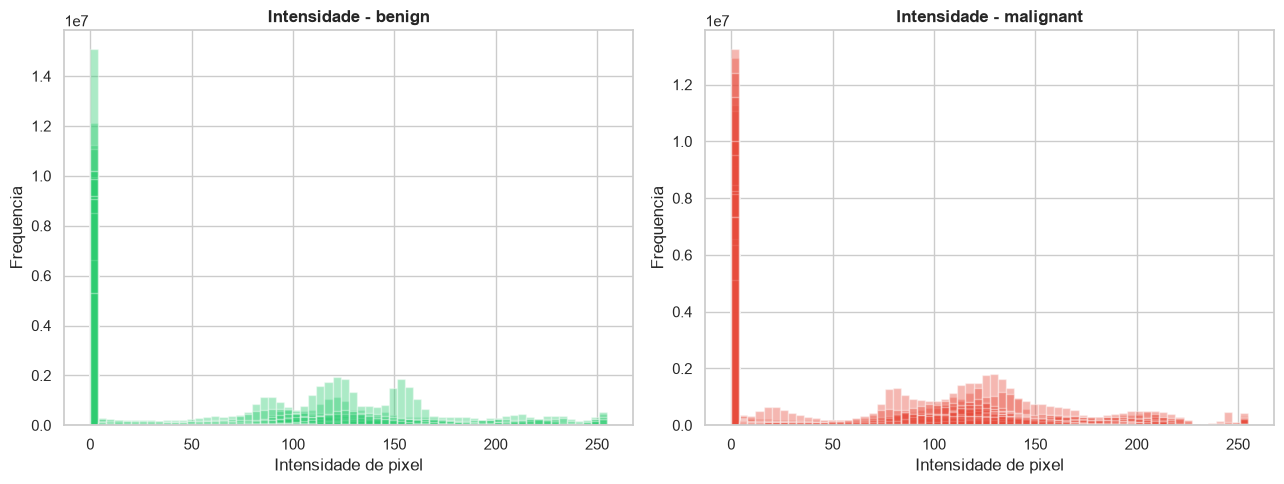

In [6]:
# Celula 6 - Histograma de intensidade por classe
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, label in zip(axes, ['benign', 'malignant']):
    subset = df_stats[df_stats['label'] == label]
    for _, row in subset.iterrows():
        with Image.open(row['path']) as im:
            arr = np.array(im.convert('L'))
        ax.hist(arr.ravel(), bins=64, alpha=0.4,
                color='#2ecc71' if label == 'benign' else '#e74c3c')
    ax.set_title(f'Intensidade - {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Intensidade de pixel')
    ax.set_ylabel('Frequencia')
plt.tight_layout()
plt.show()

In [7]:
# Celula 7 - Insights e conclusoes
print('''
=========== INSIGHTS DA ANALISE DE IMAGENS ===========
1. ESTRUTURA: dataset organizado em train/val/test, classes benign/malignant.
2. DESBALANCEAMENTO: ha menos casos malignos do que benignos (esperado em
   triagem) -> Focal Loss + WeightedRandomSampler no treino da CNN.
3. IMAGENS GRANDES: mamografias em alta resolucao -> resize para 224x224
   e normalizacao ImageNet no pipeline da CNN.
4. CONTRASTE: histogramas mostram fundo escuro com tecido mamario em tons
   de cinza -> valores de pixel nao normalizados sao ruidosos para a rede;
   a normalizacao e essencial.
5. PRE-PROCESSAMENTO: usar create_dataloaders() (augmentation no treino)
   e treinar com transfer learning (MobileNetV2).
=========================================================
''')


=========== INSIGHTS DA ANALISE DE IMAGENS ===========
1. ESTRUTURA: dataset organizado em train/val/test, classes benign/malignant.
2. DESBALANCEAMENTO: ha menos casos malignos do que benignos (esperado em
   triagem) -> Focal Loss + WeightedRandomSampler no treino da CNN.
3. IMAGENS GRANDES: mamografias em alta resolucao -> resize para 224x224
   e normalizacao ImageNet no pipeline da CNN.
4. CONTRASTE: histogramas mostram fundo escuro com tecido mamario em tons
   de cinza -> valores de pixel nao normalizados sao ruidosos para a rede;
   a normalizacao e essencial.
5. PRE-PROCESSAMENTO: usar create_dataloaders() (augmentation no treino)
   e treinar com transfer learning (MobileNetV2).

